# Week 6 Day 2 Lab
### Problem 1
Create a neural network with:
- 2 input features
- 8 hidden neurons
- ReLU activation
- 1 sigmoid output neuron


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    tf.keras.Input(shape=(2,)), Dense(8, activation='relu'), Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
    )

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

### Problem 2
Create your own dataset and train the model for:

- 50 epochs
- 100 epochs
- 300 epochs

Compare the results.


In [6]:
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

X = np.random.rand(1000, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

epoch_values = [50, 100, 300]
results = {}

for epochs in epoch_values:
    model = Sequential([
        tf.keras.Input(shape=(2,)), Dense(8, activation='relu'), Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
    )

    history = model.fit(X, y, epochs=epochs, batch_size=32, verbose=0)

    loss, accuracy = model.evaluate(X, y, verbose=0)
    results[epochs] = {'loss': loss, 'accuracy': accuracy}

    print(f"Epochs: {epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
    print()

Epochs: 50, Loss: 0.2175, Accuracy: 0.9740

Epochs: 100, Loss: 0.1232, Accuracy: 0.9960

Epochs: 300, Loss: 0.0548, Accuracy: 0.9970



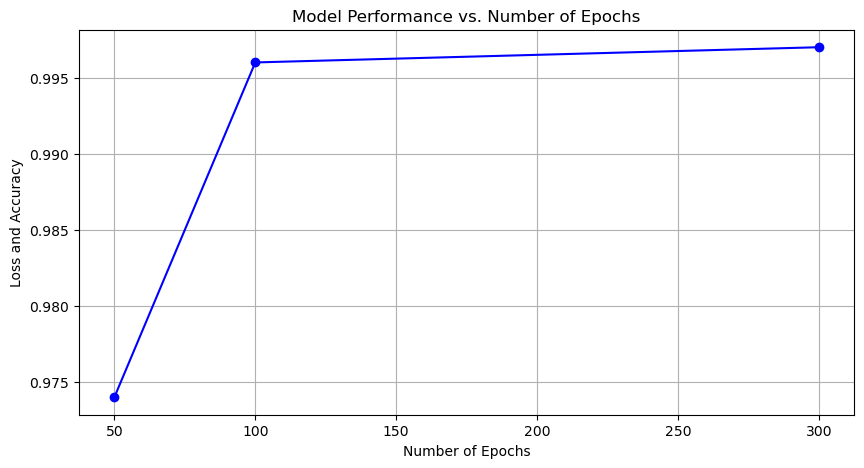

In [9]:
import matplotlib.pyplot as plt

epochs = list(results.keys())
accuracies = [results[epoch]['accuracy'] for epoch in epochs]

plt.figure(figsize=(10, 5))
plt.plot(epochs, accuracies, marker='o', label='Accuracy', color='blue')

plt.title('Model Performance vs. Number of Epochs')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss and Accuracy')
plt.grid()
plt.show()

### Problem 3

Replace the optimizer:

```python
optimizer="sgd"
```

Compare it with:

```python
optimizer="adam"
```


In [10]:
np.random.seed(42)
tf.random.set_seed(42)

X = np.random.rand(1000, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

optimizers = ['adam', 'sgd']
optimizer_results = {}

for optimizer in optimizers:
    model = Sequential([
        tf.keras.Input(shape=(2,)), Dense(8, activation='relu'), Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy']
    )

    history = model.fit(X, y, epochs=100, batch_size=32, verbose=0)

    loss, accuracy = model.evaluate(X, y, verbose=0)
    optimizer_results[optimizer] = {'loss': loss, 'accuracy': accuracy}

    print(f"Optimizer: {optimizer}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
    print()

Optimizer: adam, Loss: 0.1297, Accuracy: 0.9960

Optimizer: sgd, Loss: 0.2299, Accuracy: 0.9740



### Problem 4
Create a neural network for the Iris dataset using:

- Input layer
- One hidden layer
- Three output neurons
- Softmax activation

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [14]:
iris  = pd.read_csv("/Users/lukelewis/Applications/anaconda3/pkgs/bokeh-3.4.1-py312h8e4b320_0/lib/python3.12/site-packages/bokeh/sampledata/_data/iris.csv")

print(iris.head())
print(iris.columns)
print(set(iris['species']))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
{'versicolor', 'setosa', 'virginica'}


In [16]:
X = iris.drop(columns=['species'])
y = iris['species']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tf.random.set_seed(42)

iris_model = Sequential([
    tf.keras.Input(shape=(4,)), Dense(8, activation ='relu'), Dense(3, activation='softmax')
])
iris_model.compile(
    optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']
)
iris_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)

test_loss, test_accuracy = iris_model.evaluate(X_test_scaled, y_test, verbose=0)

print('Test accuracy: ', test_accuracy)

probabilities = iris_model.predict(X_test_scaled, verbose=0)

predictions = np.argmax(probabilities, axis=1)

predicted_species = label_encoder.inverse_transform(predictions)
actual_species = label_encoder.inverse_transform(y_test)

comparison = pd.DataFrame({'Actual': actual_species, 'Predicted': predicted_species})

print(comparison.head(10))

Test accuracy:  0.8333333134651184
       Actual   Predicted
0  versicolor   virginica
1      setosa      setosa
2   virginica   virginica
3  versicolor   virginica
4  versicolor   virginica
5      setosa      setosa
6  versicolor  versicolor
7   virginica   virginica
8  versicolor   virginica
9  versicolor  versicolor
